In [1]:
from qiskit import QuantumCircuit
from qiskit.compiler import transpile
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
import numpy as np
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke
from qiskit.quantum_info import Operator

from tqdm import tqdm

In [2]:
from pmns import PMNS_matrix_4x4
from hamiltonians import U1_omega_Omega, theta_ij, J_ij
from hamiltonians import nunu_interaction as nunu_interaction

In [3]:
simulator=AerSimulator()
N = 4

In [4]:
#### Defining PMNS matrix and parameters for the Hamiltonian ####
theta_12 = np.radians(33.67)
theta_13 = np.radians(8.58)
theta_23 = np.radians(42.3)
delta_CP = np.radians(232)

U_PMNS_4x4 = PMNS_matrix_4x4(theta_12, theta_13, theta_23, delta_CP)
assert np.allclose(U_PMNS_4x4.conj().T @ U_PMNS_4x4, np.eye(4)), "PMNS matrix is not unitary"

dm21 = 7.41e-5
dm31 = 2.505e-3
E = 1.0

delta_m21 = dm21
delta_m31 = dm31
delta_m32 = delta_m31 - delta_m21
#mu=dm31*N/(2*E) #* 1e-8
mu = dm31 * N / (2 * E)
#omega = np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3) / (4 * E)
omega=dm21 / (2 * E)  
Omega= dm31 / (2 * E)
#B3 = delta_m21 / np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3)
#B8 = (delta_m31 + delta_m32) / (np.sqrt(3) * np.sqrt(delta_m21**2 + ((delta_m31 + delta_m32)**2) / 3))
B3=0.025483
B8=0.999567
B = np.zeros(8)
B[2] = B3
B[7] = B8

In [5]:
def apply_nunu_interaction(qc, pair_indices, alpha_list):
    for i, j, alpha_ij in alpha_list:
        q = [2*i, 2*i+1, 2*j, 2*j+1]
        nunu_interaction(qc, q, alpha_ij)


Measurement counts: {'00010010': 8192}
Measurement counts: {'01000100': 1, '00011000': 1, '10101000': 1, '00101001': 8, '01000001': 4, '10010110': 1, '10100100': 1, '10000001': 4, '00000110': 4, '00100101': 9, '00000001': 23, '01101000': 2, '01010100': 1, '01000101': 1, '00000100': 1, '01100001': 10, '00000101': 1, '00000000': 2, '00010000': 62, '00100110': 27, '01010110': 2, '10100010': 18, '01000010': 3, '00100010': 1502, '10000010': 4, '10001001': 1, '10010100': 9, '01010001': 26, '00100001': 811, '00011001': 17, '10000000': 4, '00010101': 38, '01100000': 42, '00011010': 46, '00010001': 1528, '00010110': 74, '10010010': 47, '01011010': 1, '00010010': 3151, '01100010': 38, '01011000': 1, '10010001': 3, '01010000': 76, '10100001': 5, '01010010': 80, '00100000': 27, '00000010': 94, '10100000': 120, '10010000': 238, '01000000': 2, '00101010': 20}
Measurement counts: {'01001001': 2, '10100110': 1, '01010101': 2, '10011000': 2, '00001010': 2, '10010010': 2, '01101001': 6, '10011001': 1, '

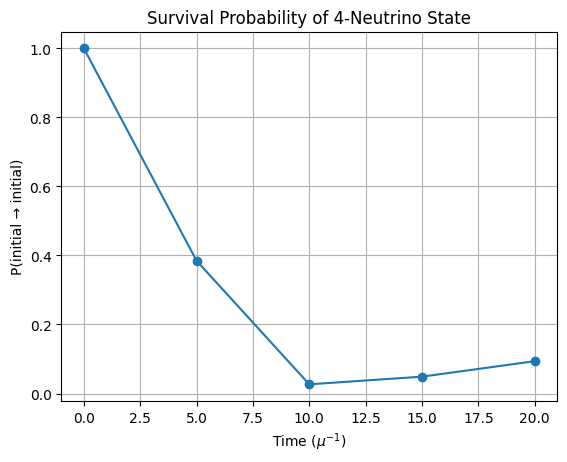

In [6]:
# Time loop setup for N neutrinos

pair_indices = [(i, j) for i in range(N) for j in range(i+1, N)]
dt = 5 / mu
T_max = 20 / mu
steps = int(T_max / dt) + 1
times = np.linspace(0, T_max, steps)

probabilities = []
shots = 8192
for t in times:
    qc = QuantumCircuit(2 * N, 2 * N)

    # Initial state: alternate nu_e, nu_mu, nu_e, nu_tau pattern
    for i in range(N):
        if i % 4 == 1:
            qc.x(2*i + 1)  # nu_mu = |01⟩
        elif i % 4 == 3:
            qc.x(2*i)      # nu_tau = |10⟩

    # Apply U†_PMNS
    Udag = Operator(U_PMNS_4x4.conj().T)
    for i in range(N):
        qc.unitary(Udag, [2*i, 2*i+1], label="U†_PMNS")

    # Trotterization
    Trotter = int(t / dt)
    for _ in range(Trotter):
        pair_alphas = [(i, j, J_ij(i, j, E, mu, N) * dt) for i, j in pair_indices]
        for i in range(N):
            qc.append(U1_omega_Omega(dt, omega, Omega), [2*i, 2*i+1])

        apply_nunu_interaction(qc, pair_indices, pair_alphas)

    # Apply U_PMNS
    U = Operator(U_PMNS_4x4)
    for i in range(N):
        qc.unitary(U, [2*i, 2*i+1], label="U_PMNS")

    # Measurement
    qc.measure(range(2 * N), reversed((range(2 * N))))

    pqc = transpile(qc, simulator, optimization_level=3)

    #pqc = transpile(qc, basis_gates=["u3", "cx"])
    job = simulator.run([pqc], shots=shots)
    job_result = job.result()
    counts = job_result.get_counts()

    # Target initial state pattern: 00 01 00 10 00 01 00 10 ...
    # Target initial state pattern based on same logic as initial state
    base_pattern = []
    for i in range(N):
        if i % 4 == 1:
            base_pattern.append('01')  # nu_mu
        elif i % 4 == 3:
            base_pattern.append('10')  # nu_tau
        else:
            base_pattern.append('00')  # nu_e
    # Reverse the *pairs*, not individual bits
    target_state = ''.join((base_pattern))

    #print("Target state:", target_state)
    

    prob = counts.get(target_state, 0) / shots
    print("Measurement counts:", counts)
    probabilities.append(prob)

# Plot
plt.plot(times * mu, probabilities, marker='o')
plt.xlabel(r"Time ($\mu^{-1}$)")
plt.ylabel("P(initial → initial)")
plt.title("Survival Probability of {0}-Neutrino State".format(N))
plt.grid(True)
plt.savefig("survi_prob_{0}_nu.png".format(N))
